This notebook is to display and compare the results I personally conducted and the results found by the paper. This is to make sure what we're getting is correct!

## Import libraries

In [1]:
import matplotlib.pyplot as plt

In [2]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [3]:
def plotStats( X, plots, xLabel, yLabel, title, log_scale = False, i = 0, ylim = -1 ):

    for label, plot in plots:
        if( i == 0 ):
            plt.plot(X, plot, label=label )
        else:
            plt.plot(X[:i], plot[:i], label=label)

    if( log_scale ):
        plt.yscale( "log" )
        plt.ylabel( yLabel + " (Log Scaled)" )
    else:
        if( ylim > 0 ):
            plt.ylim(0, ylim)
        plt.ylabel(yLabel)
    plt.grid()
    plt.xlabel(xLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

## Real World Applications

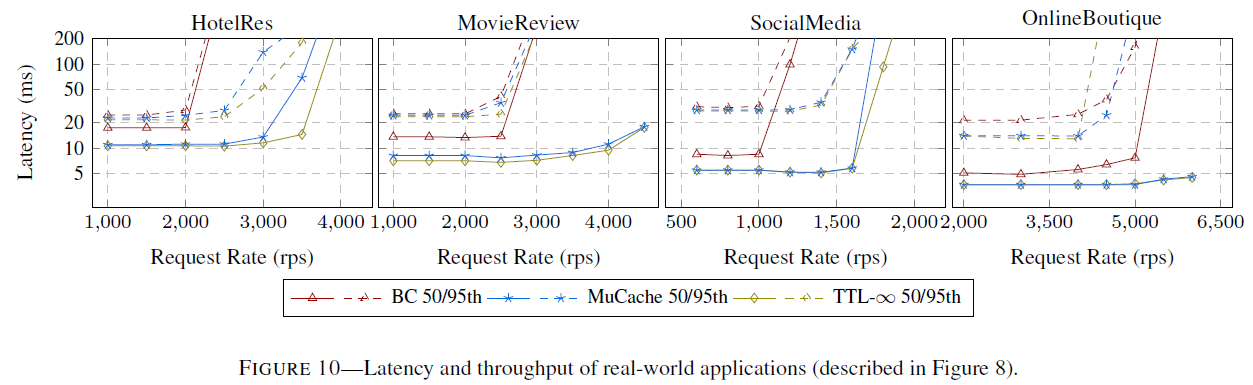

For Hotel benchmark, enabling a prefetching scheme requires more in-depth code that has the service read a file and retrieve the map from location index to location name. To avoid tampering with too much, I've decided to skip hotel for now

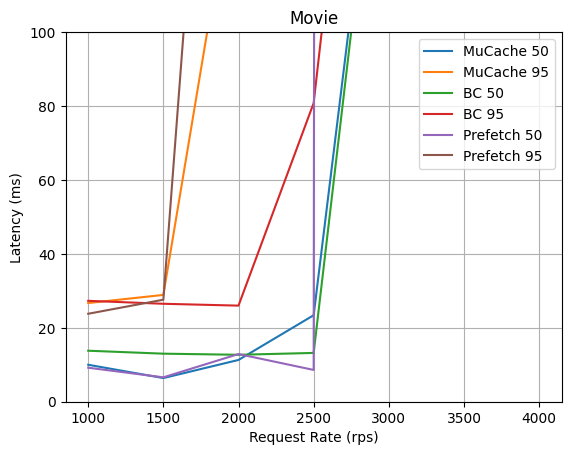

In [41]:
# MovieReview
x, bc_out = getStats( "movie-baseline-prefetch-2neighbor-original-context-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "movie-prefetch-2neighbor-original-context-5000app-12proxy-4zmq.json" )
# _, ttl_out = getStats( "movie-upper-5000app-12proxy-4zmq.json" )
# _, batch_out = getStats( "movie-batch-5000app-12proxyworkers-4zmq.json" )
_, prefetch_out = getStats( "movie-prefetch-prefetch-1neighbor-original-context-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         # ["Batch 50", batch_out["50"]],
         # ["Batch 95", batch_out["95"]]]
         ["Prefetch 50", prefetch_out["50"]],
         ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

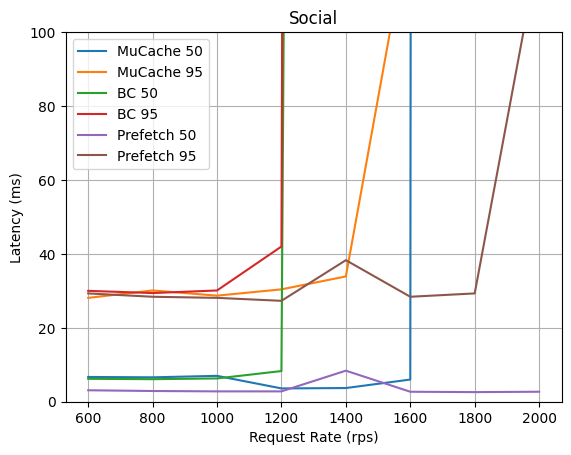

In [38]:
# SocialMedia
x, bc_out = getStats( "social-baseline-2neighbor.json" )
_, mucache_out = getStats( "social-2neighbor.json" )
#_, ttl_out = getStats( "social-upper-5000app-12proxy-4zmq.json" )
_, prefetch_out = getStats( "social-prefetch-prefetch-mimicRequest-20ms-prefetch-1neighbor-call-args-mimic.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         # ["Batch 50", batch_out["50"]],
         # ["Batch 95", batch_out["95"]]]
         ["Prefetch 50", prefetch_out["50"]],
         ["Prefetch 95", prefetch_out["95"]],]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )

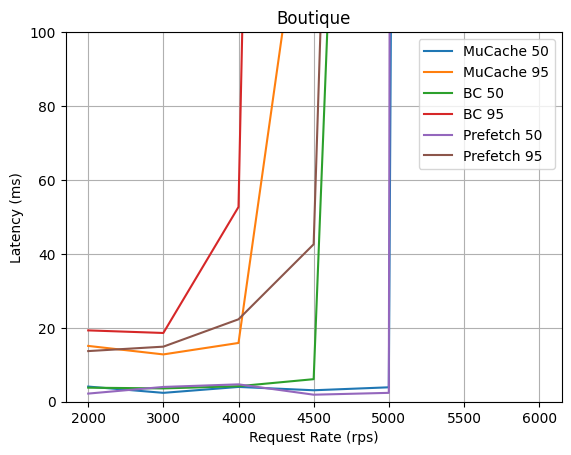

In [39]:
# OnlineBoutique
x, bc_out = getStats( "boutique-baseline-test-nearby-2neighbor-originalContextWith10msTimeOut-2.json" )
_, mucache_out = getStats( "boutique-test-nearby-2neighbor-originalContextWith10msTimeOut-2.json" )
# _, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
# _, batch_out = getStats( "boutique-batch-halfSize-5000app-12proxy-4zmq-2.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-prefetch.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-nearby-1neighbor-10ms.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-nearby-2neighbor-10msTimeout.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-nearby-1neighbor-originalContextWith10msTimeOut.json" )
_, prefetch_out = getStats( "boutique-prefetch-nearbyUsers-1neighbor-originalContextWith20msTimeOut-halfProductSize-5000app-12proxy-4zmq-mimicContext.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         # ["Batch 50", batch_out["50"]],
         # ["Batch 95", batch_out["95"]],]
         ["Prefetch 50", prefetch_out["50"]],
         ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim=100 )

### Analysis
By adding Prefetching, we can see similar to better performances compared to MuCache. However, these experiments revealed that fine-tuning is required, as many of the services couldn't handle prefetching multiple items without latency spikes. However, we do show that latency does indeed improve the performance of MuCache pretty significantly.